In [ ]:
!pip install -q tensorflow==2.21.0 keras==3.15.1 keras-hub==0.32.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 125.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 MB 13.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.20.1 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.21.0 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is inc

In [ ]:
import tensorflow as tf
import keras
import keras_hub

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("KerasHub:", keras_hub.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
Keras: 3.15.1
KerasHub: 0.32.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path

EVAL_ROOT = Path("/content/drive/MyDrive/NutriVision_Evaluation")

CHECKPOINT = (
    EVAL_ROOT
    / "production_checkpoints"
    / "best_model.weights.h5"
)

DEV_ROOT = EVAL_ROOT / "dev_500"
DEV_IMAGES = DEV_ROOT / "images"
DEV_MASKS = DEV_ROOT / "masks"

print("Checkpoint:", CHECKPOINT.exists())
print("Images:", DEV_IMAGES.exists())
print("Masks:", DEV_MASKS.exists())

Checkpoint: True
Images: True
Masks: True


In [ ]:
image_names = sorted(
    p.name for p in DEV_IMAGES.iterdir()
    if p.is_file()
)

print("Images found:", len(image_names))

Images found: 500


In [ ]:
dev_names = image_names

print("Evaluation images:", len(dev_names))
print("First:", dev_names[:3])
print("Last:", dev_names[-3:])

Evaluation images: 500
First: ['00008.jpg', '00016.jpg', '00017.jpg']
Last: ['04954.jpg', '04961.jpg', '04975.jpg']


In [ ]:
missing = []

for name in dev_names:
    if not (DEV_MASKS / Path(name).with_suffix(".png").name).exists():
        missing.append(name)

print("Missing masks:", len(missing))

Missing masks: 0


In [ ]:
NUM_CLASSES = 104
PRESET = "segformer_b2_ade20k_512"

model = keras_hub.models.SegFormerImageSegmenter.from_preset(
    PRESET,
    num_classes=NUM_CLASSES
)

print(model.input_shape)
print(model.output_shape)

100%|██████████| 1.66k/1.66k [00:00<00:00, 1.16MB/s]


100%|██████████| 4.71k/4.71k [00:00<00:00, 3.88MB/s]


(None, 512, 512, 3)
(None, 512, 512, 104)


In [ ]:
model.load_weights(CHECKPOINT)

print("Checkpoint loaded successfully.")

Checkpoint loaded successfully.


In [ ]:
IOU_THRESHOLD = 0.50
MIN_AREA_VALUES = [250, 500]

print("Remaining evaluations:", MIN_AREA_VALUES)

Remaining evaluations: [250, 500]


In [ ]:
import cv2
import numpy as np

def mask_to_boxes(mask, min_area):
    boxes = []

    for class_id in range(1, 104):
        binary = (mask == class_id).astype(np.uint8)

        n, labels, stats, _ = cv2.connectedComponentsWithStats(
            binary, connectivity=8
        )

        for component_id in range(1, n):
            x, y, w, h, area = stats[component_id]

            if area < min_area:
                continue

            boxes.append({
                "class_id": class_id,
                "box": np.array(
                    [x, y, x + w, y + h],
                    dtype=np.float32
                )
            })

    return boxes

In [ ]:
def box_iou(a, b):
    x1 = max(a[0], b[0])
    y1 = max(a[1], b[1])
    x2 = min(a[2], b[2])
    y2 = min(a[3], b[3])

    inter = max(0, x2 - x1) * max(0, y2 - y1)

    area_a = max(0, a[2] - a[0]) * max(0, a[3] - a[1])
    area_b = max(0, b[2] - b[0]) * max(0, b[3] - b[1])

    union = area_a + area_b - inter

    return inter / union if union > 0 else 0.0

In [ ]:
def match_boxes(gt_boxes, pred_boxes, threshold=0.50):
    candidates = []

    for gi, gt in enumerate(gt_boxes):
        for pi, pred in enumerate(pred_boxes):

            if gt["class_id"] != pred["class_id"]:
                continue

            iou = box_iou(gt["box"], pred["box"])

            if iou >= threshold:
                candidates.append((iou, gi, pi))

    candidates.sort(reverse=True)

    used_gt = set()
    used_pred = set()
    matched_ious = []

    for iou, gi, pi in candidates:

        if gi in used_gt or pi in used_pred:
            continue

        used_gt.add(gi)
        used_pred.add(pi)
        matched_ious.append(iou)

    tp = len(matched_ious)
    fp = len(pred_boxes) - tp
    fn = len(gt_boxes) - tp

    return tp, fp, fn, matched_ious

In [ ]:
from PIL import Image
import tensorflow as tf

remaining_results = {}

for min_area in MIN_AREA_VALUES:

    tp_total = 0
    fp_total = 0
    fn_total = 0
    matched_ious = []

    print(f"\nEvaluating min_area={min_area}")

    for i, image_name in enumerate(dev_names):

        image_path = DEV_IMAGES / image_name
        mask_path = DEV_MASKS / Path(image_name).with_suffix(".png").name

        image = Image.open(image_path).convert("RGB")
        original_w, original_h = image.size

        # Same preprocessing used during training
        image_512 = image.resize((512, 512))

        x = np.asarray(image_512, dtype=np.float32) / 255.0

        x = (
            x - np.array([0.485, 0.456, 0.406], dtype=np.float32)
        ) / np.array([0.229, 0.224, 0.225], dtype=np.float32)

        x = np.expand_dims(x, axis=0)

        # Inference
        logits = model(
            tf.convert_to_tensor(x),
            training=False
        )

        pred_mask_512 = tf.argmax(
            logits,
            axis=-1
        )[0].numpy().astype(np.uint8)

        # Return to original image size
        pred_mask = cv2.resize(
            pred_mask_512,
            (original_w, original_h),
            interpolation=cv2.INTER_NEAREST
        )

        gt_mask = np.array(
            Image.open(mask_path),
            dtype=np.uint8
        )

        gt_boxes = mask_to_boxes(gt_mask, min_area)
        pred_boxes = mask_to_boxes(pred_mask, min_area)

        tp, fp, fn, ious = match_boxes(
            gt_boxes,
            pred_boxes,
            IOU_THRESHOLD
        )

        tp_total += tp
        fp_total += fp
        fn_total += fn
        matched_ious.extend(ious)

        if (i + 1) % 25 == 0:
            print(f"{i + 1}/500")

    precision = (
        tp_total / (tp_total + fp_total)
        if tp_total + fp_total else 0
    )

    recall = (
        tp_total / (tp_total + fn_total)
        if tp_total + fn_total else 0
    )

    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall else 0
    )

    mean_iou = (
        float(np.mean(matched_ious))
        if matched_ious else 0
    )

    remaining_results[min_area] = {
        "TP": tp_total,
        "FP": fp_total,
        "FN": fn_total,
        "precision": precision,
        "recall": recall,
        "F1": f1,
        "mean_IoU": mean_iou
    }

    print(
        f"TP={tp_total}, "
        f"FP={fp_total}, "
        f"FN={fn_total}, "
        f"Precision={precision:.4f}, "
        f"Recall={recall:.4f}, "
        f"F1={f1:.4f}, "
        f"Mean IoU={mean_iou:.4f}"
    )


Evaluating min_area=250
25/500
50/500
75/500
100/500
125/500
150/500
175/500
200/500
225/500
250/500
275/500
300/500
325/500
350/500
375/500
400/500
425/500
450/500
475/500
500/500
TP=1421, FP=3219, FN=1435, Precision=0.3063, Recall=0.4975, F1=0.3791, Mean IoU=0.8624

Evaluating min_area=500
25/500
50/500
75/500
100/500
125/500
150/500
175/500
200/500
225/500
250/500
275/500
300/500
325/500
350/500
375/500
400/500
425/500
450/500
475/500
500/500
TP=1404, FP=2564, FN=1373, Precision=0.3538, Recall=0.5056, F1=0.4163, Mean IoU=0.8643


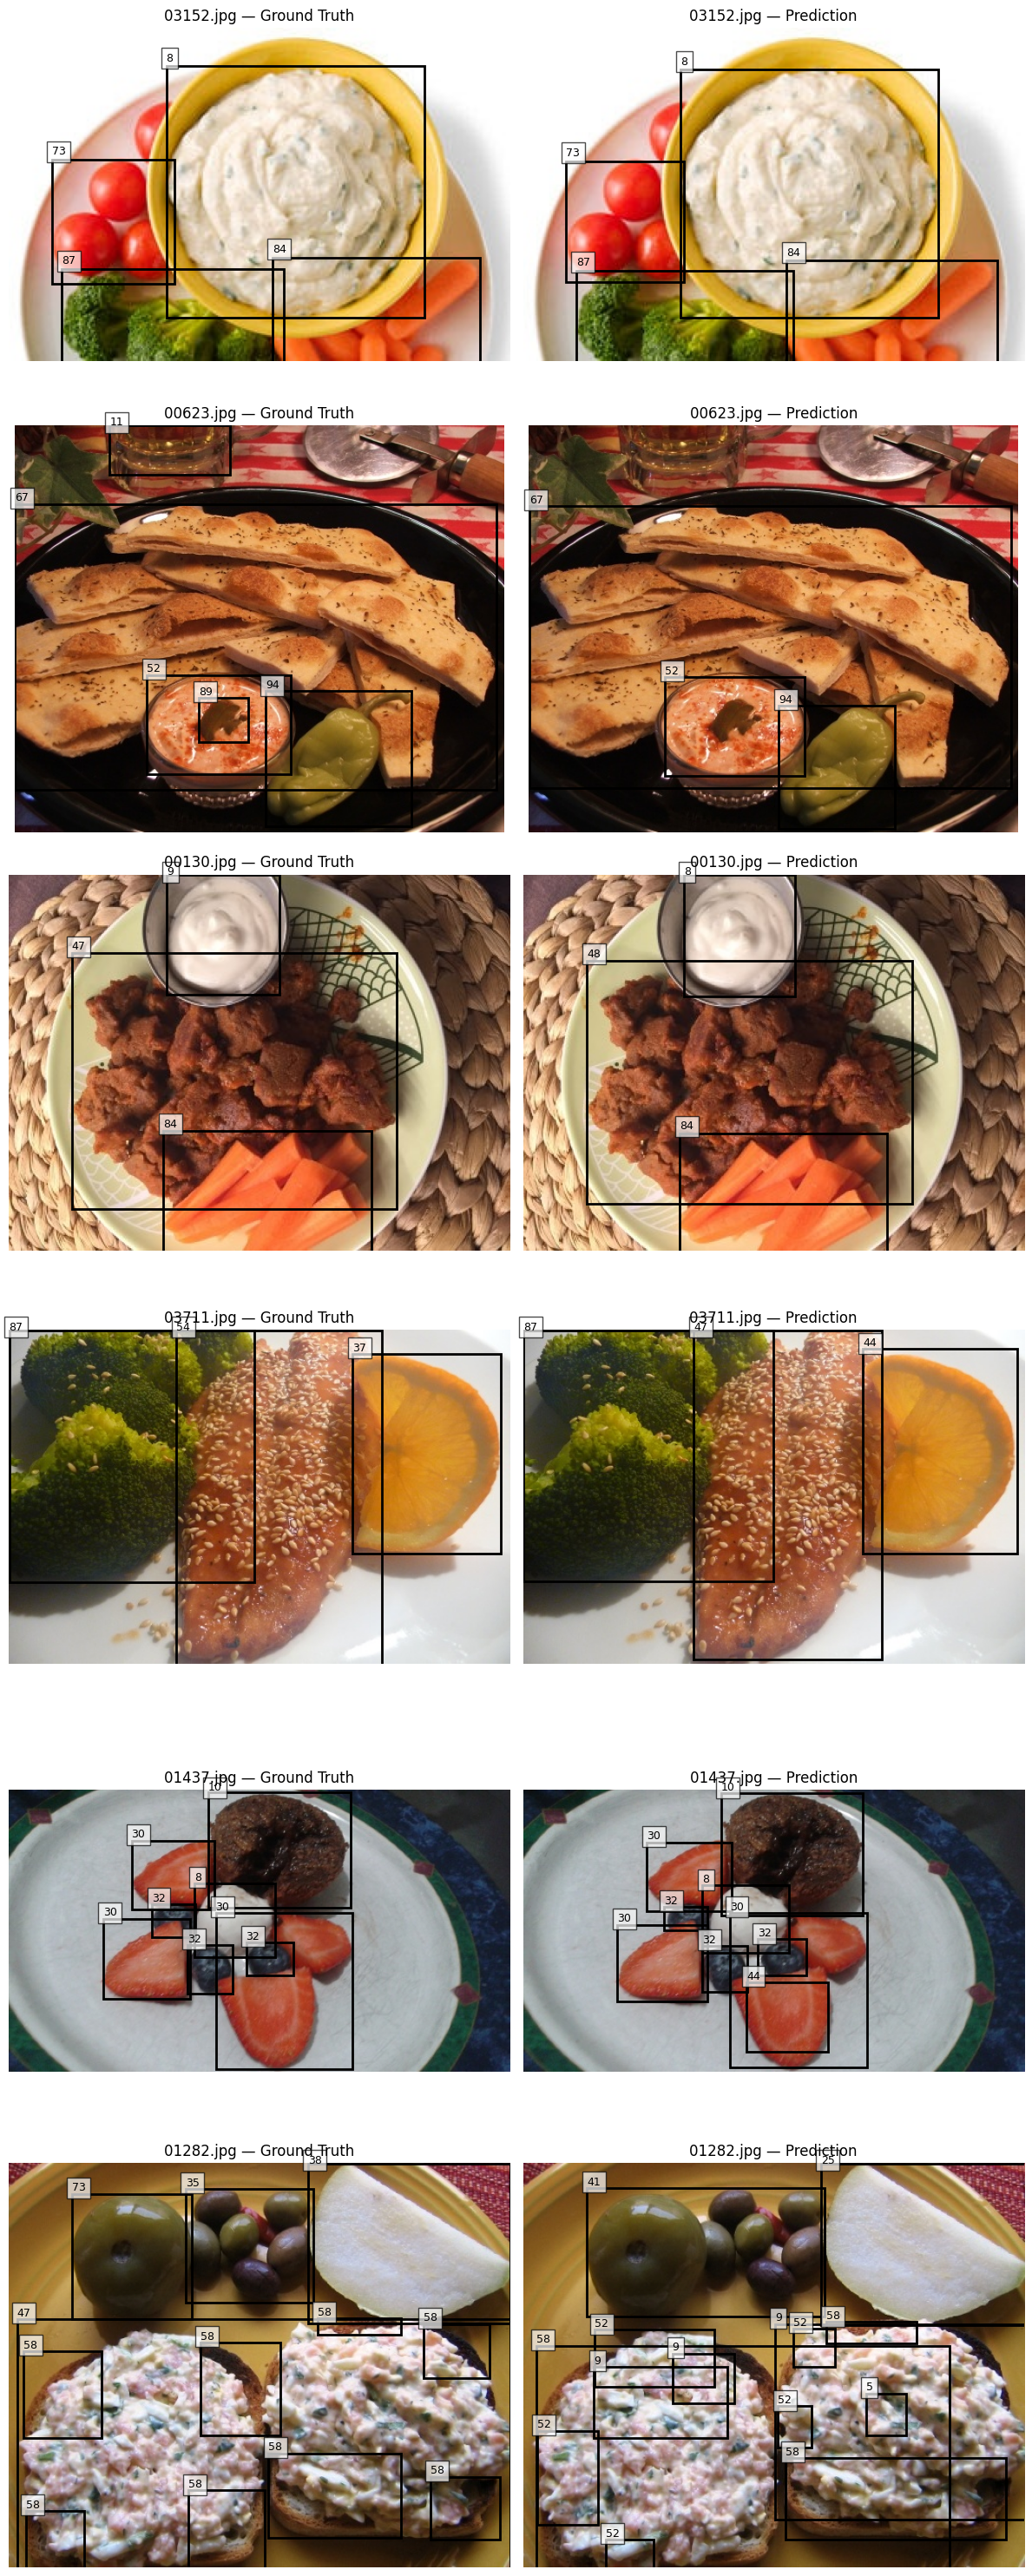

In [ ]:
import random
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

random.seed(42)

sample_names = random.sample(dev_names, 6)

def draw_boxes(ax, image, boxes, title):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

    for item in boxes:
        x1, y1, x2, y2 = item["box"]
        class_id = item["class_id"]

        rect = Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2
        )

        ax.add_patch(rect)

        ax.text(
            x1,
            max(0, y1 - 3),
            str(class_id),
            fontsize=9,
            bbox=dict(facecolor="white", alpha=0.7)
        )

fig, axes = plt.subplots(
    len(sample_names),
    2,
    figsize=(12, 5 * len(sample_names))
)

for row, image_name in enumerate(sample_names):

    image_path = DEV_IMAGES / image_name
    mask_path = DEV_MASKS / Path(image_name).with_suffix(".png").name

    image = Image.open(image_path).convert("RGB")
    original_w, original_h = image.size

    # Ground truth
    gt_mask = np.array(Image.open(mask_path), dtype=np.uint8)
    gt_boxes = mask_to_boxes(gt_mask, 500)

    # Prediction
    image_512 = image.resize((512, 512))

    x = np.asarray(image_512, dtype=np.float32) / 255.0

    x = (
        x - np.array([0.485, 0.456, 0.406], dtype=np.float32)
    ) / np.array([0.229, 0.224, 0.225], dtype=np.float32)

    x = np.expand_dims(x, axis=0)

    logits = model(
        tf.convert_to_tensor(x),
        training=False
    )

    pred_mask_512 = tf.argmax(
        logits,
        axis=-1
    )[0].numpy().astype(np.uint8)

    pred_mask = cv2.resize(
        pred_mask_512,
        (original_w, original_h),
        interpolation=cv2.INTER_NEAREST
    )

    pred_boxes = mask_to_boxes(pred_mask, 500)

    draw_boxes(
        axes[row, 0],
        image,
        gt_boxes,
        f"{image_name} — Ground Truth"
    )

    draw_boxes(
        axes[row, 1],
        image,
        pred_boxes,
        f"{image_name} — Prediction"
    )

plt.tight_layout()
plt.show()

In [ ]:
GT_MIN_AREA = 20
PRED_MIN_AREA_VALUES = [20, 50, 100, 250, 500]

print("Ground-truth min_area:", GT_MIN_AREA)
print("Prediction min_area values:", PRED_MIN_AREA_VALUES)
print("Ground truth: FIXED")
print("Prediction threshold: VARIED")

Ground-truth min_area: 20
Prediction min_area values: [20, 50, 100, 250, 500]
Ground truth: FIXED
Prediction threshold: VARIED


In [ ]:
corrected_results = {
    min_area: {
        "TP": 0,
        "FP": 0,
        "FN": 0,
        "matched_ious": []
    }
    for min_area in PRED_MIN_AREA_VALUES
}

print("Prepared thresholds:", list(corrected_results.keys()))

Prepared thresholds: [20, 50, 100, 250, 500]


In [ ]:
for i, image_name in enumerate(dev_names):

    image_path = DEV_IMAGES / image_name
    mask_path = DEV_MASKS / Path(image_name).with_suffix(".png").name

    image = Image.open(image_path).convert("RGB")
    original_w, original_h = image.size

    # Preprocessing
    image_512 = image.resize((512, 512))
    x = np.asarray(image_512, dtype=np.float32) / 255.0

    x = (
        x - np.array([0.485, 0.456, 0.406], dtype=np.float32)
    ) / np.array([0.229, 0.224, 0.225], dtype=np.float32)

    x = np.expand_dims(x, axis=0)

    # ONE model inference
    logits = model(
        tf.convert_to_tensor(x),
        training=False
    )

    pred_mask_512 = tf.argmax(
        logits,
        axis=-1
    )[0].numpy().astype(np.uint8)

    # Restore prediction to original size
    pred_mask = cv2.resize(
        pred_mask_512,
        (original_w, original_h),
        interpolation=cv2.INTER_NEAREST
    )

    # FIXED ground truth
    gt_mask = np.array(
        Image.open(mask_path),
        dtype=np.uint8
    )

    gt_boxes = mask_to_boxes(
        gt_mask,
        GT_MIN_AREA
    )

    # Test prediction thresholds
    for min_area in PRED_MIN_AREA_VALUES:

        pred_boxes = mask_to_boxes(
            pred_mask,
            min_area
        )

        tp, fp, fn, ious = match_boxes(
            gt_boxes,
            pred_boxes,
            IOU_THRESHOLD
        )

        corrected_results[min_area]["TP"] += tp
        corrected_results[min_area]["FP"] += fp
        corrected_results[min_area]["FN"] += fn
        corrected_results[min_area]["matched_ious"].extend(ious)

    if (i + 1) % 25 == 0:
        print(f"{i + 1}/500")

KeyboardInterrupt: 

In [ ]:
FINAL_VAL_ZIP = EVAL_ROOT / "raw_foodseg103_val.zip"

print("ZIP exists:", FINAL_VAL_ZIP.exists())

if FINAL_VAL_ZIP.exists():
    print("Size (GB):", round(FINAL_VAL_ZIP.stat().st_size / (1024**3), 3))

ZIP exists: True
Size (GB): 0.185


In [ ]:
import zipfile

FINAL_VAL_ROOT = EVAL_ROOT / "raw_foodseg103_val"

with zipfile.ZipFile(FINAL_VAL_ZIP, "r") as z:
    z.extractall(EVAL_ROOT)

print("Extraction complete.")
print("Images:", len(list((FINAL_VAL_ROOT / "images").glob("*.jpg"))))
print("Masks :", len(list((FINAL_VAL_ROOT / "masks").glob("*.png"))))

Extraction complete.
Images: 0
Masks : 0


In [ ]:
for p in EVAL_ROOT.rglob("images"):
    print("Images folder found:", p)

for p in EVAL_ROOT.rglob("masks"):
    print("Masks folder found:", p)

Images folder found: /content/drive/MyDrive/NutriVision_Evaluation/images
Masks folder found: /content/drive/MyDrive/NutriVision_Evaluation/masks


In [ ]:
FINAL_VAL_IMAGES = EVAL_ROOT / "images"
FINAL_VAL_MASKS = EVAL_ROOT / "masks"

print("Images:", len(list(FINAL_VAL_IMAGES.glob("*.jpg"))))
print("Masks :", len(list(FINAL_VAL_MASKS.glob("*.png"))))

Images: 2135
Masks : 2135


In [ ]:
final_val_names = sorted(
    p.name for p in FINAL_VAL_IMAGES.glob("*.jpg")
)

print("Validation images:", len(final_val_names))
print("First 5:", final_val_names[:5])
print("Last 5:", final_val_names[-5:])

Validation images: 2135
First 5: ['00000.jpg', '00001.jpg', '00002.jpg', '00003.jpg', '00004.jpg']
Last 5: ['02130.jpg', '02131.jpg', '02132.jpg', '02133.jpg', '02134.jpg']


In [ ]:
image_name = final_val_names[0]

image = Image.open(
    FINAL_VAL_IMAGES / image_name
).convert("RGB")

original_w, original_h = image.size

image_512 = image.resize((512, 512))

x = np.asarray(
    image_512,
    dtype=np.float32
) / 255.0

x = (
    x - np.array([0.485, 0.456, 0.406], dtype=np.float32)
) / np.array([0.229, 0.224, 0.225], dtype=np.float32)

x = np.expand_dims(x, axis=0)

logits = model(
    tf.convert_to_tensor(x),
    training=False
)

pred_mask = tf.argmax(
    logits,
    axis=-1
)[0]

print("Image:", image_name)
print("Original size:", (original_w, original_h))
print("Logits:", logits.shape)
print("Prediction:", pred_mask.shape)
print(
    "Predicted class range:",
    int(tf.reduce_min(pred_mask)),
    "to",
    int(tf.reduce_max(pred_mask))
)

Image: 00000.jpg
Original size: (512, 485)
Logits: (1, 512, 512, 104)
Prediction: (512, 512)
Predicted class range: 0 to 101


In [ ]:
FINAL_MIN_AREA = 500

final_tp = 0
final_fp = 0
final_fn = 0
final_ious = []

for i, image_name in enumerate(final_val_names):

    image_path = FINAL_VAL_IMAGES / image_name
    mask_path = FINAL_VAL_MASKS / Path(image_name).with_suffix(".png").name

    image = Image.open(image_path).convert("RGB")
    original_w, original_h = image.size

    # Same preprocessing used during training
    image_512 = image.resize((512, 512))

    x = np.asarray(
        image_512,
        dtype=np.float32
    ) / 255.0

    x = (
        x - np.array([0.485, 0.456, 0.406], dtype=np.float32)
    ) / np.array([0.229, 0.224, 0.225], dtype=np.float32)

    x = np.expand_dims(x, axis=0)

    # Inference
    logits = model(
        tf.convert_to_tensor(x),
        training=False
    )

    pred_mask_512 = tf.argmax(
        logits,
        axis=-1
    )[0].numpy().astype(np.uint8)

    # Restore to original image dimensions
    pred_mask = cv2.resize(
        pred_mask_512,
        (original_w, original_h),
        interpolation=cv2.INTER_NEAREST
    )

    # Ground truth
    gt_mask = np.array(
        Image.open(mask_path),
        dtype=np.uint8
    )

    # Fixed GT threshold + chosen prediction threshold
    gt_boxes = mask_to_boxes(gt_mask, GT_MIN_AREA)
    pred_boxes = mask_to_boxes(pred_mask, FINAL_MIN_AREA)

    tp, fp, fn, ious = match_boxes(
        gt_boxes,
        pred_boxes,
        IOU_THRESHOLD
    )

    final_tp += tp
    final_fp += fp
    final_fn += fn
    final_ious.extend(ious)

    if (i + 1) % 100 == 0:
        print(f"{i + 1}/2135")

final_precision = (
    final_tp / (final_tp + final_fp)
    if final_tp + final_fp else 0
)

final_recall = (
    final_tp / (final_tp + final_fn)
    if final_tp + final_fn else 0
)

final_f1 = (
    2 * final_precision * final_recall /
    (final_precision + final_recall)
    if final_precision + final_recall else 0
)

final_mean_iou = (
    float(np.mean(final_ious))
    if final_ious else 0
)

print("\n===== FINAL FOODSEG103 VALIDATION =====")
print("Images:", len(final_val_names))
print("TP:", final_tp)
print("FP:", final_fp)
print("FN:", final_fn)
print(f"Precision: {final_precision:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"F1:        {final_f1:.4f}")
print(f"Mean IoU:  {final_mean_iou:.4f}")

100/2135
200/2135
300/2135
400/2135
500/2135
600/2135
700/2135
800/2135
900/2135
1000/2135
1100/2135
1200/2135
1300/2135
1400/2135
1500/2135
1600/2135
1700/2135
1800/2135
1900/2135
2000/2135
2100/2135

===== FINAL FOODSEG103 VALIDATION =====
Images: 2135
TP: 5822
FP: 10338
FN: 6177
Precision: 0.3603
Recall:    0.4852
F1:        0.4135
Mean IoU:  0.8612


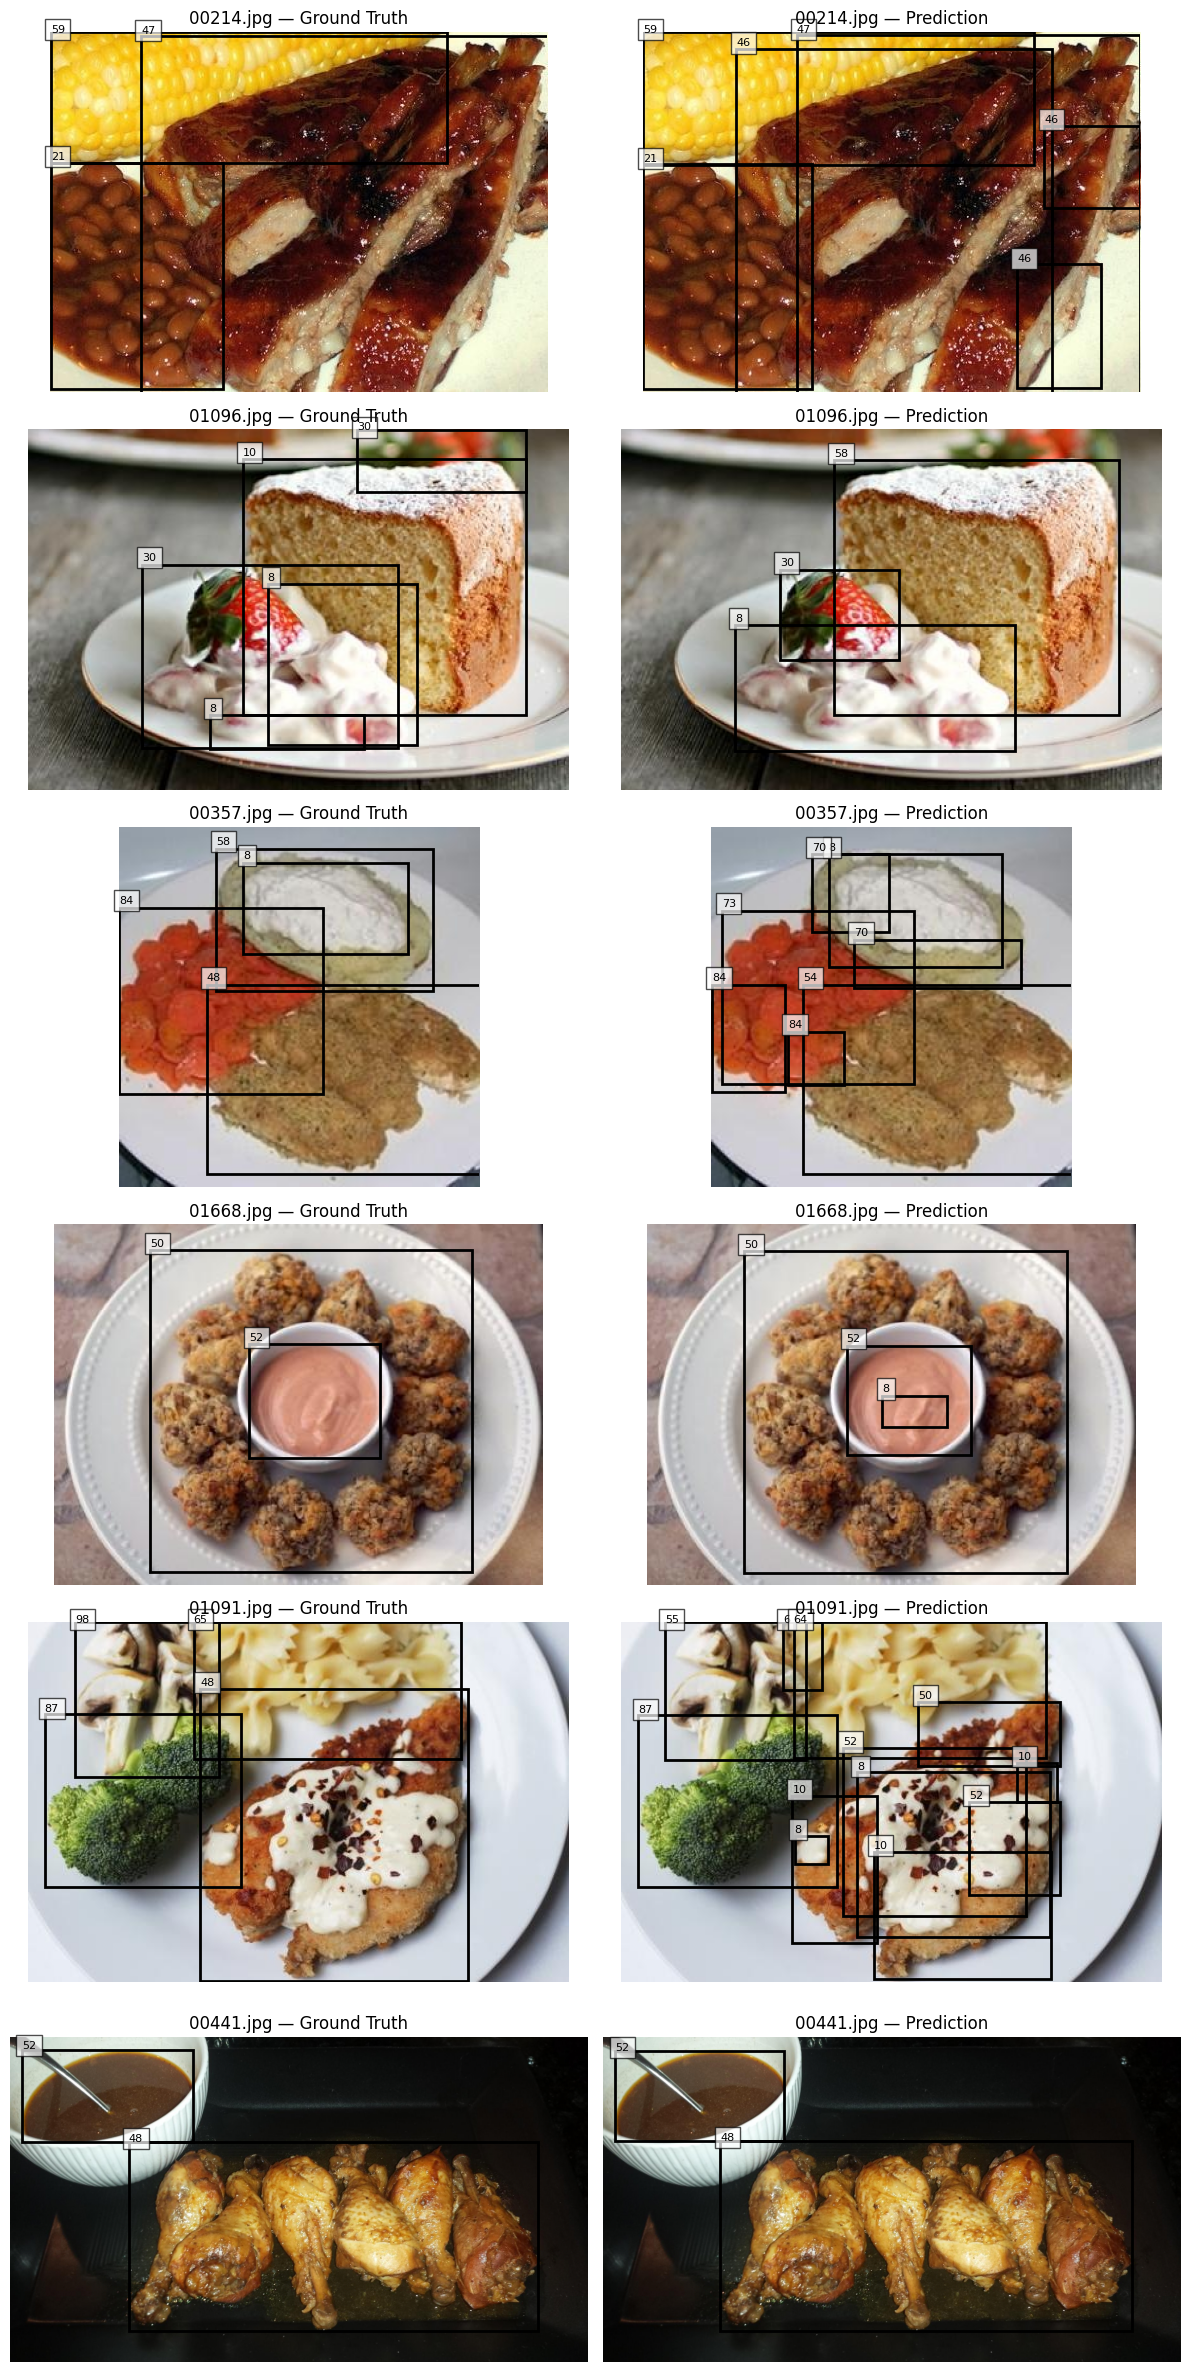

In [ ]:
import random
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

random.seed(123)

sample_names = random.sample(final_val_names, 6)

fig, axes = plt.subplots(
    6, 2,
    figsize=(12, 24)
)

for row, image_name in enumerate(sample_names):

    image_path = FINAL_VAL_IMAGES / image_name
    mask_path = FINAL_VAL_MASKS / Path(image_name).with_suffix(".png").name

    image = Image.open(image_path).convert("RGB")
    original_w, original_h = image.size

    # Ground truth
    gt_mask = np.array(
        Image.open(mask_path),
        dtype=np.uint8
    )

    gt_boxes = mask_to_boxes(
        gt_mask,
        GT_MIN_AREA
    )

    # Prediction
    image_512 = image.resize((512, 512))

    x = np.asarray(
        image_512,
        dtype=np.float32
    ) / 255.0

    x = (
        x - np.array([0.485, 0.456, 0.406], dtype=np.float32)
    ) / np.array([0.229, 0.224, 0.225], dtype=np.float32)

    x = np.expand_dims(x, axis=0)

    logits = model(
        tf.convert_to_tensor(x),
        training=False
    )

    pred_mask_512 = tf.argmax(
        logits,
        axis=-1
    )[0].numpy().astype(np.uint8)

    pred_mask = cv2.resize(
        pred_mask_512,
        (original_w, original_h),
        interpolation=cv2.INTER_NEAREST
    )

    pred_boxes = mask_to_boxes(
        pred_mask,
        FINAL_MIN_AREA
    )

    # Draw ground truth
    axes[row, 0].imshow(image)
    axes[row, 0].set_title(
        f"{image_name} — Ground Truth"
    )
    axes[row, 0].axis("off")

    for item in gt_boxes:
        x1, y1, x2, y2 = item["box"]

        axes[row, 0].add_patch(
            Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                linewidth=2
            )
        )

        axes[row, 0].text(
            x1,
            max(0, y1 - 3),
            str(item["class_id"]),
            fontsize=8,
            bbox=dict(facecolor="white", alpha=0.7)
        )

    # Draw prediction
    axes[row, 1].imshow(image)
    axes[row, 1].set_title(
        f"{image_name} — Prediction"
    )
    axes[row, 1].axis("off")

    for item in pred_boxes:
        x1, y1, x2, y2 = item["box"]

        axes[row, 1].add_patch(
            Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                linewidth=2
            )
        )

        axes[row, 1].text(
            x1,
            max(0, y1 - 3),
            str(item["class_id"]),
            fontsize=8,
            bbox=dict(facecolor="white", alpha=0.7)
        )

plt.tight_layout()
plt.show()

In [ ]:
FINAL_MODEL_DIR = EVAL_ROOT / "final_model"
FINAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)

FINAL_CHECKPOINT = FINAL_MODEL_DIR / "nutrivision_segformer_b2.weights.h5"

import shutil

shutil.copy2(
    CHECKPOINT,
    FINAL_CHECKPOINT
)

print("Final checkpoint saved:", FINAL_CHECKPOINT)
print("Size (MB):", round(FINAL_CHECKPOINT.stat().st_size / (1024**2), 2))

Final checkpoint saved: /content/drive/MyDrive/NutriVision_Evaluation/final_model/nutrivision_segformer_b2.weights.h5
Size (MB): 105.4


In [ ]:
final_model = keras_hub.models.SegFormerImageSegmenter.from_preset(
    PRESET,
    num_classes=NUM_CLASSES
)

final_model.load_weights(FINAL_CHECKPOINT)

print("Final model reloaded successfully.")
print("Input :", final_model.input_shape)
print("Output:", final_model.output_shape)

Final model reloaded successfully.
Input : (None, 512, 512, 3)
Output: (None, 512, 512, 104)


In [ ]:
image_name = final_val_names[0]

image_path = FINAL_VAL_IMAGES / image_name
image = Image.open(image_path).convert("RGB")

original_w, original_h = image.size

image_512 = image.resize((512, 512))

x = np.asarray(image_512, dtype=np.float32) / 255.0
x = (
    x - np.array([0.485, 0.456, 0.406], dtype=np.float32)
) / np.array([0.229, 0.224, 0.225], dtype=np.float32)

x = np.expand_dims(x, axis=0)

logits = final_model(
    tf.convert_to_tensor(x),
    training=False
)

pred_mask_512 = tf.argmax(logits, axis=-1)[0].numpy().astype(np.uint8)

pred_mask = cv2.resize(
    pred_mask_512,
    (original_w, original_h),
    interpolation=cv2.INTER_NEAREST
)

pred_boxes = mask_to_boxes(
    pred_mask,
    FINAL_MIN_AREA
)

print("Image:", image_name)
print("Original size:", (original_w, original_h))
print("Logits shape:", logits.shape)
print("Prediction mask:", pred_mask.shape)
print("Predicted class range:", pred_mask.min(), "to", pred_mask.max())
print("Detected food regions:", len(pred_boxes))

Image: 00000.jpg
Original size: (512, 485)
Logits shape: (1, 512, 512, 104)
Prediction mask: (485, 512)
Predicted class range: 0 to 101
Detected food regions: 7


In [ ]:
FINAL_KERAS_MODEL = FINAL_MODEL_DIR / "nutrivision_segformer_b2.keras"

final_model.save(FINAL_KERAS_MODEL)

print("Complete Keras model saved:")
print(FINAL_KERAS_MODEL)
print("Size (MB):", round(FINAL_KERAS_MODEL.stat().st_size / (1024**2), 2))

Complete Keras model saved:
/content/drive/MyDrive/NutriVision_Evaluation/final_model/nutrivision_segformer_b2.keras
Size (MB): 105.36


In [45]:
loaded_keras_model = keras.models.load_model(
    FINAL_KERAS_MODEL,
    compile=False
)

print("Complete .keras model reloaded successfully.")
print("Input :", loaded_keras_model.input_shape)
print("Output:", loaded_keras_model.output_shape)

Complete .keras model reloaded successfully.
Input : (None, 512, 512, 3)
Output: (None, 512, 512, 104)


In [46]:
image_name = final_val_names[0]

image_path = FINAL_VAL_IMAGES / image_name
image = Image.open(image_path).convert("RGB")

original_w, original_h = image.size

image_512 = image.resize((512, 512))

x = np.asarray(image_512, dtype=np.float32) / 255.0

x = (
    x - np.array([0.485, 0.456, 0.406], dtype=np.float32)
) / np.array([0.229, 0.224, 0.225], dtype=np.float32)

x = np.expand_dims(x, axis=0)

logits = loaded_keras_model(
    tf.convert_to_tensor(x),
    training=False
)

pred_mask_512 = tf.argmax(
    logits, axis=-1
)[0].numpy().astype(np.uint8)

pred_mask = cv2.resize(
    pred_mask_512,
    (original_w, original_h),
    interpolation=cv2.INTER_NEAREST
)

pred_boxes = mask_to_boxes(
    pred_mask,
    FINAL_MIN_AREA
)

print("Final .keras inference check")
print("----------------------------")
print("Image:", image_name)
print("Logits:", logits.shape)
print("Prediction mask:", pred_mask.shape)
print("Detected food regions:", len(pred_boxes))
print("Predicted class range:", pred_mask.min(), "to", pred_mask.max())

Final .keras inference check
----------------------------
Image: 00000.jpg
Logits: (1, 512, 512, 104)
Prediction mask: (485, 512)
Detected food regions: 7
Predicted class range: 0 to 101
